# VAE hyperparameter search for cat faces

## Imports

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from scripts import (
    DataFixedConfig,
    DataGridConfig,
    TrainFixedConfig,
    TrainGridConfig,
    VAEExperiment,
    VAEFixedConfig,
    VAEGridConfig,
    build_dataloaders,
    build_vae,
    compute_fid,
    count_parameters,
    expand_experiment_grid,
    output_paths,
    prepare_data,
    report_fid,
    resolve_device,
    run_name,
    save_history,
    save_history_plot,
    save_json,
    save_sample_grid,
    train_vae,
    update_total_stats,
    vae_sample_iterator,
)

## Parameters

In [2]:
# Hyperparameter sweep on the cats-faces dataset (same data config as
# 01_vae_3_faces.ipynb: augment_flip=False, posterize_bits=6, base_channels=96, AMP).
#
# Grid: latent_dim x beta x learning_rate = 3 x 2 x 2 = 12 runs.
# kl_anneal_epochs, weight_decay, batch_size and epochs are kept fixed at the
# values that worked well in 01_vae_3_faces.ipynb. Early stopping patience is
# reduced (20 -> 10) so configs that plateau or diverge don't burn the full
# epoch budget.

EXPERIMENT_NAME = "vae"

# --- Data ---------------------------------------------------------------
DATA_DIR = "../data/cats-faces"
OUTPUT_DIR = "../reports/runs"
CACHE_DIR = "../.cache/fid"
IMAGE_SIZE = 64
TRAIN_FRACTION = 0.9
VALIDATION_FRACTION = 0.1
AUGMENT_FLIP = False
GRAYSCALE = False
POSTERIZE_BITS = 6

# --- Model (fixed) -------------------------------------------------------
HIDDEN_DIM = 512
BASE_CHANNELS = 96
AMP = True

# --- Model grid (swept) ---------------------------------------------------
LATENT_DIMS = [64, 128, 256]
BETAS = [0.5, 0.8]
LEARNING_RATES = [5e-4, 1e-3]

# --- Model (fixed) --------------------------------------------------------
KL_ANNEAL_EPOCHS = 20
WEIGHT_DECAY = 1e-5

# --- Optimization ----------------------------------------------------------
EPOCHS = 40
BATCH_SIZE = 64
SEED = 42

# --- Early stopping --------------------------------------------------------
EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 0.5
EARLY_STOPPING_RESTORE_BEST = True

# --- Checkpointing -----------------------------------------------------------
SAVE_CHECKPOINT = True

# --- Logging / sampling -----------------------------------------------------
SAMPLE_EVERY = 10
FID_REAL_SAMPLES = 5000
FID_FAKE_SAMPLES = 5000
DEVICE = "cuda"
PROGRESS_BACKEND = "terminal"

experiment = VAEExperiment(
    name=EXPERIMENT_NAME,
    data_fixed=DataFixedConfig(
        data_dir=DATA_DIR,
        cache_dir=CACHE_DIR,
        output_dir=OUTPUT_DIR,
        image_size=IMAGE_SIZE,
        channels=1 if GRAYSCALE else 3,
        grayscale=GRAYSCALE,
        posterize_bits=POSTERIZE_BITS,
    ),
    data_grid=DataGridConfig(
        train_fraction=TRAIN_FRACTION,
        validation_fraction=VALIDATION_FRACTION,
        augment_flip=AUGMENT_FLIP,
        seed=SEED,
    ),
    train_fixed=TrainFixedConfig(
        device=DEVICE,
        progress_backend=PROGRESS_BACKEND,
        fid_real_samples=FID_REAL_SAMPLES,
        fid_fake_samples=FID_FAKE_SAMPLES,
        early_stopping=EARLY_STOPPING,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
        early_stopping_restore_best=EARLY_STOPPING_RESTORE_BEST,
    ),
    train_grid=TrainGridConfig(
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        sample_every=SAMPLE_EVERY,
    ),
    model_fixed=VAEFixedConfig(
        base_channels=BASE_CHANNELS,
        hidden_dim=HIDDEN_DIM,
        amp=AMP,
    ),
    model_grid=VAEGridConfig(
        latent_dim=LATENT_DIMS,
        beta=BETAS,
        learning_rate=LEARNING_RATES,
        weight_decay=WEIGHT_DECAY,
        kl_anneal_epochs=KL_ANNEAL_EPOCHS,
    ),
)

runs = expand_experiment_grid(experiment)
print(f"Generated {len(runs)} configuration(s) to train.")

Generated 12 configuration(s) to train.


## Data

The data grid is a single configuration (only the model grid is swept), so the dataset is prepared once and reused for every run.

In [3]:
torch.manual_seed(SEED)
np.random.seed(SEED)

data_params = runs[0]["data"]
prepared = prepare_data(
    experiment.data_fixed,
    train_fraction=data_params["train_fraction"],
    validation_fraction=data_params["validation_fraction"],
    augment_flip=data_params["augment_flip"],
    seed=data_params["seed"],
)
print(f"Train images: {len(prepared.train_dataset)} | Validation: {len(prepared.validation_dataset)}")

train_loader, validation_loader = build_dataloaders(
    prepared,
    experiment.data_fixed,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

device = resolve_device(experiment.train_fixed.device)
print(f"Using device: {device}")

Train images: 14172 | Validation: 1575
Using device: cuda


## Hyperparameter sweep

Trains, evaluates (FID) and saves artifacts for each of the 12 grid configurations.

In [4]:
results = []

for i, run in enumerate(runs, start=1):
    model_params = run["model"]
    print(
        f"\n=== Run {i}/{len(runs)}: latent_dim={model_params['latent_dim']} "
        f"beta={model_params['beta']} learning_rate={model_params['learning_rate']} ==="
    )

    torch.manual_seed(run["data"]["seed"])
    np.random.seed(run["data"]["seed"])

    run_dir = run_name(experiment.kind, run)
    paths = output_paths(experiment.name, experiment.data_fixed.output_dir, run_dir)
    save_json(paths["configs"] / "run.json", {"experiment": experiment.name, **run})

    model = build_vae(model_params, experiment.model_fixed, experiment.data_fixed)
    print(f"VAE parameters: {count_parameters(model):,}")

    training_result = train_vae(
        model,
        train_loader,
        validation_loader,
        model_params=model_params,
        train_params=run["train"],
        train_fixed=experiment.train_fixed,
        fixed_params=experiment.model_fixed,
        sample_dir=paths["samples"],
        checkpoint_path=paths["checkpoints"] / "vae_final.pt" if SAVE_CHECKPOINT else None,
    )

    history = training_result["history"]
    save_history(history, paths["metrics"] / "history.csv")
    save_history_plot(
        history,
        paths["figures"] / "loss_curves.png",
        metrics=["loss", "validation_loss", "reconstruction", "kl"],
        title="VAE Loss Curves",
    )
    elapsed = training_result["elapsed_seconds"]
    print(f"Trained in {int(elapsed // 60):02d}:{int(elapsed % 60):02d} on {training_result['device']}.")
    update_total_stats(
        experiment.data_fixed.output_dir,
        experiment.kind,
        run_dir,
        experiment.name,
        elapsed,
        training_result["device"],
    )

    with torch.no_grad():
        z = torch.randn(64, model.latent_dim, device=device)
        save_sample_grid(model.decode(z), paths["figures"] / "samples_final.png", nrow=8)

    sampler = vae_sample_iterator(
        model,
        num_samples=experiment.train_fixed.fid_fake_samples,
        batch_size=run["train"]["batch_size"],
        device=device,
        seed=run["data"]["seed"],
    )
    fid_start = time.perf_counter()
    fid_score = compute_fid(
        sampler,
        experiment.data_fixed,
        num_real_samples=experiment.train_fixed.fid_real_samples,
        seed=run["data"]["seed"],
        device=device,
    )
    fid_elapsed = time.perf_counter() - fid_start
    report_fid(fid_score, elapsed_seconds=fid_elapsed)
    save_json(paths["metrics"] / "fid.json", {"fid": fid_score, "elapsed_seconds": fid_elapsed})

    last = history[-1]
    results.append({
        "run_dir": run_dir,
        "latent_dim": model_params["latent_dim"],
        "beta": model_params["beta"],
        "learning_rate": model_params["learning_rate"],
        "epochs_run": len(history),
        "fid": fid_score,
        "val_loss": last["validation_loss"],
        "val_reconstruction": last["validation_reconstruction"],
        "val_kl": last["validation_kl"],
        "elapsed_seconds": elapsed,
    })

    del model
    torch.cuda.empty_cache()


=== Run 1/12: latent_dim=64 beta=0.5 learning_rate=0.0005 ===
VAE parameters: 25,096,323
Using device: cuda
VAE parameters: 25,096,323
AMP enabled (fp16 autocast + GradScaler).


VAE Training: 100%|██████████| 40/40 [09:19<00:00, 13.98s/it, beta=0.500, kl=135.061, loss=324.730, val=413.184] 

Restored best VAE weights from epoch 40.


Saved VAE checkpoint to ..\reports\runs\vae\20260613_182541_vae_z64_b0_5_lr0_0005_e40\checkpoints\vae_final.pt.
VAE training finished in 00:09:19
Trained in 09:19 on cuda.


Generated → Inception: 79it [00:09,  8.46it/s]


...

VAE Training: 100%|██████████| 40/40 [08:58<00:00, 13.47s/it, beta=0.800, kl=108.016, loss=407.681, val=475.488] 

Restored best VAE weights from epoch 40.


Saved VAE checkpoint to ..\reports\runs\vae\20260613_200519_vae_z256_b0_8_lr0_001_e40\checkpoints\vae_final.pt.
VAE training finished in 00:08:59
Trained in 08:59 on cuda.


Generated → Inception: 79it [00:09,  8.65it/s]


FID: 49.333 (sampling took 00:00:20)


## Results

In [5]:
results_df = pd.DataFrame(results).sort_values("fid").reset_index(drop=True)
results_df.to_csv(Path(OUTPUT_DIR) / experiment.name / "hyperparam_search_summary.csv", index=False)
results_df

,run_dir,latent_dim,beta,learning_rate,epochs_run,fid,val_loss,val_reconstruction,val_kl,elapsed_seconds
0,20260613_192748_vae_z128_b0_8_lr0_001_e40,128,0.8,0.0010,40,44.882769,471.153564,378.967514,115.232560,512.428294
1,20260613_190954_vae_z128_b0_5_lr0_001_e40,128,0.5,0.0010,40,48.301246,428.806599,357.703984,142.205226,492.212235
2,20260613_193647_vae_z256_b0_5_lr0_0005_e40,256,0.5,0.0005,40,49.212697,419.126451,343.792304,150.668290,531.873360
3,20260613_200519_vae_z256_b0_8_lr0_001_e40,256,0.8,0.0010,40,49.332971,475.488050,388.524668,108.704229,539.111919
4,20260613_190126_vae_z128_b0_5_lr0_0005_e40,128,0.5,0.0005,40,50.155392,413.528815,334.892443,157.272743,488.240723
5,20260613_195535_vae_z256_b0_8_lr0_0005_e40,256,0.8,0.0005,40,50.834569,459.007832,364.724499,117.854159,554.242779
6,20260613_194602_vae_z256_b0_5_lr0_001_e40,256,0.5,0.0010,40,51.732762,432.483942,363.251235,138.465409,545.659674
7,20260613_191853_vae_z128_b0_8_lr0_0005_e40,128,0.8,0.0005,40,52.674135,452.258923,353.292680,123.707795,513.499264
8,20260613_185301_vae_z64_b0_8_lr0_001_e40,64,0.8,0.0010,40,53.110760,472.244479,383.150196,111.367855,483.981592
9,20260613_183522_vae_z64_b0_5_lr0_001_e40,64,0.5,0.0010,40,53.487353,422.247983,356.575226,131.345510,506.953580


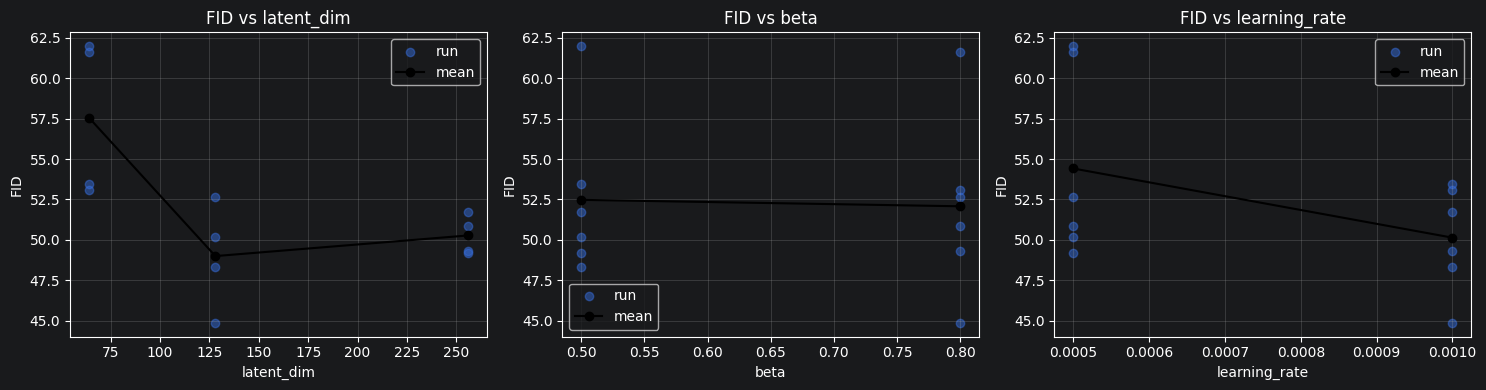

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, param in zip(axes, ["latent_dim", "beta", "learning_rate"]):
    means = results_df.groupby(param)["fid"].mean()
    ax.scatter(results_df[param], results_df["fid"], alpha=0.5, label="run")
    ax.plot(means.index, means.values, marker="o", color="black", label="mean")
    ax.set_xlabel(param)
    ax.set_ylabel("FID")
    ax.set_title(f"FID vs {param}")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()